In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
from sklearn.base import RegressorMixin, BaseEstimator
from sklearn.utils.validation import validate_data, check_is_fitted


class BaseLinearRegression(RegressorMixin, BaseEstimator):
    def __init__(self, fit_intercept=True):
        self.fit_intercept = fit_intercept
    def predict(self, X):
        check_is_fitted(self)
        X = validate_data(
            self,
            X,
            reset=False,
            dtype=float,
        )
        predictions = X@self.coef_ + self.intercept_
        return predictions

In [36]:
class MyLinearRegressionClosedForm(BaseLinearRegression):
    def fit(self,X,y):
        if(self.fit_intercept):
            one = np.ones((X.shape[0],1))
            ones_X = np.concatenate((one, X),axis = 1)
        else:
            ones_X = X
        weights = np.linalg.lstsq(ones_X,y,rcond = None)[0]
        if self.fit_intercept:
            self.intercept_ = weights[0]
            self.coef_ = weights[1:]
        else:
            self.intercept_ = 0
            self.coef_ = weights
        return self
class MyLinearRegressionBatchGD(BaseLinearRegression):
    def __init__(self,fit_intercept = True, num_epochs = 100,learning_rate = 0.01):
        super().__init__(fit_intercept = fit_intercept)
        self.learning_rate = learning_rate
        self.num_epochs = num_epochs
    def fit(self,X,y):
        if(self.fit_intercept):
            one = np.ones((X.shape[0],1))
            ones_X = np.concatenate((one, X),axis = 1)
        else:
            ones_X = X
        weights = np.zeros(ones_X.shape[1])
        self.loss_history_ = []
        for i in range(self.num_epochs):
            loss = 1/2 * np.mean((y - ones_X @ weights)**2)
            self.loss_history_.append(loss)
            dW = - ones_X.T @ (y - ones_X @ weights) / X.shape[0]
            weights -= self.learning_rate * dW
            print(f"Epochs {i} || Loss: {loss}")
        if self.fit_intercept:
            self.intercept_ = weights[0]
            self.coef_ = weights[1:]
        else:
            self.intercept_ = 0
            self.coef_ = weights
        return self
class MyLinearRegressionMiniBatchGD(BaseLinearRegression):
    def __init__(self,fit_intercept = True, num_epochs = 100, learning_rate = 0.01, batch_size = 32):
        super().__init__(fit_intercept = fit_intercept)
        self.learning_rate = learning_rate
        self.num_epochs = num_epochs
        self.batch_size = batch_size
    def fit(self, X, y):
        if(self.fit_intercept):
            one = np.ones((X.shape[0],1))
            ones_X = np.concatenate((one,X), axis = 1)
        else:
            ones_X = X

        weights = np.zeros(ones_X.shape[1])
        self.batch_loss_history_ = []
        for i in range(self.num_epochs):
            for start in range(0, X.shape[0] , self.batch_size):
                end = start + self.batch_size
                X_batch = ones_X[start: end]
                y_batch = y[start: end]

                loss = 1 / 2 * np.mean((y_batch - X_batch@weights)**2)
                self.batch_loss_history_.append(loss)

                dw = - X_batch.T @ (y_batch - X_batch@weights) / len(X_batch)
                weights -= dw * self.learning_rate
        if(self.fit_intercept):
            self.intercept_ = weights[0]
            self.coef_ = weights[1:]
        else:
            self.intercept_ =  0
            self.coef_= weights
        return self
class MyLinearRegressionSGD(BaseLinearRegression):
    def __init__(self,fit_intercept = True, num_epochs = 100, learning_rate = 0.01):
        super().__init__(fit_intercept = fit_intercept)
        self.learning_rate = learning_rate
        self.num_epochs = num_epochs
    def fit(self,X,y):
        if(self.fit_intercept):
            one = np.ones((X.shape[0],1))
            ones_X = np.concatenate((one,X) , axis = 1)
        else:
            ones_X = X

        weights = np.zeros(ones_X.shape[1])
        self.loss_history_= []

        for i in range(self.num_epochs):
            for j in range(ones_X.shape[0]):
                loss = 1/2 * (y[j] - ones_X[j] @ weights)**2
                self.loss_history_.append(loss)
                dw = -ones_X[j] * (y[j] - ones_X[j] @ weights)
                weights -= self.learning_rate*dw
        if(self.fit_intercept):
            self.coef_ = weights[1:]
            self.intercept_ = weights[0]
        else:
            self.coef_ = weights
            self.intercept_ = 0
        return self

[ 2.00000539 -2.99999943] 3.9999708551805293


Text(0, 0.5, 'Loss')

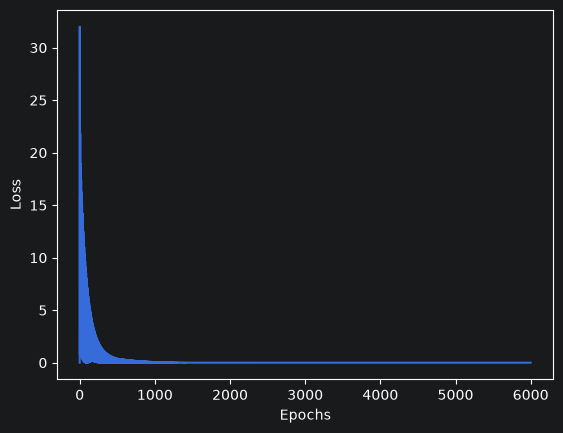

In [40]:
X = np.array([
    [1.0, 2.0],
    [2.0, 0.0],
    [3.0, 1.0],
    [4.0, 3.0],
    [5.0, 2.0],
    [6.0, 4.0],
])

y = (
    2 * X[:, 0]
    - 3 * X[:, 1]
    + 4
)
model = MyLinearRegressionSGD(num_epochs=1000)
model.fit(X,y)
print(model.coef_, model.intercept_)
plt.plot(model.loss_history_)
plt.xlabel("Epochs")
plt.ylabel("Loss")


Text(0, 0.5, 'Loss')

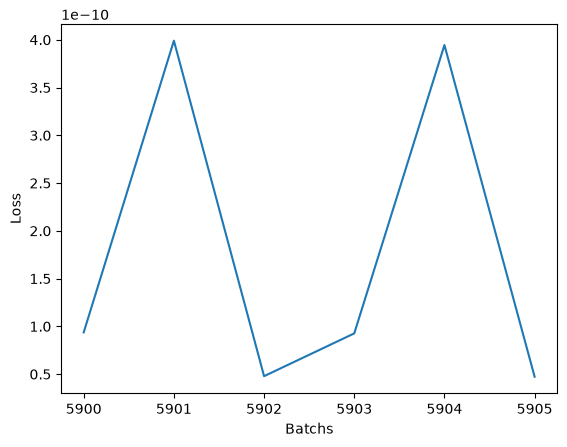

In [92]:
start = 5900
end = 5906
loss_segment = model.batch_loss_history_[start:end]
plt.plot(range(start,end), loss_segment)
plt.xlabel("Batchs")
plt.ylabel("Loss")

In [19]:
X = np.array([[1,2,3,4],
              [5,6,7,8]])
y = np.array([5,6,7,8])
print(X[0]@y)

70
